# ESMRMb 2026 - August 2026
--------------------------------------
1) Repeat and organize ESMRB26 images and poster
This script plots only dMRI data - There are no blocks interacting with b1map, tfl or flip angle maps 


In [41]:
"""
SET UP lib. and main flags
---------------------------------------------
DEBUGGING / LOGGING FLAGS
"""
import os
import json
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import subprocess
from nilearn.image import resample_to_img
import matplotlib.dates as mdates
from collections import defaultdict
from matplotlib import cm
from nilearn.image.image import mean_img #Estimate mean of a 4D volume --> mean_haxby = mean_img(func_filename)
from nilearn.plotting import plot_roi, show
from nilearn.maskers import NiftiMasker #Create a mask
import matplotlib.patches as mpatches
from scipy import stats
import pandas as pd
import pingouin as pg
from nilearn.image import smooth_img, get_data


# =====================
# === Configuration ===
# =====================

# ── Input ──────────────────────────────────────────────────────────────────── --> I left Obelix out from this pipeline
Asterix_c = [16, 17, 20, 21, 25, 26, 29, 30, 32]# 3, 33, 34, 35, 36, 39, 40, 44] #[16, 17, 21, 25, 26, 29, 30, 32, 33, 34, 35, 36, 39, 40, 44] #, 33, 34, 35, 36, 39, 40, 9998]   # ses-01
Asterix_w = [15, 18, 19, 22, 23, 24, 27, 28, 31]#, 37, 38, 41, 42, 43, 45]#[18, 19, 22, 23, 24, 27, 28, 31, 37, 38, 41, 42, 43, 45]     # ses-13  
## SET WORKING DIRECTORY
prj_path=r"/home/malberti/wks14/temp/FF_DWI_Drift" # main BIDS path /home/malberti/Unix_Folders/Sweep/Pilot/SW005
project="sub-" #Common name for folders and files, for example all my sweep files are named as "sw001_ss1_dwi_AP.nii || sw001_ss1_T1w.nii"
script=r'/home/malberti/wks14/temp/FF_DWI_Drift/Script'
PANORAMIX = f"/home/malberti/Unix_Folders/Asterix_Obelix_Population_Template/Panoramix_Template_Tmean.nii"
metric    = "MD"

# Default cube size (px, py, pz)
DEFAULT_CUBE_SIZE = (15, 15, 15)

# Default per-ROI offsets from the auto-computed centres.
# Adjust sign/magnitude here, or interactively when prompted.
DEFAULT_OFFSETS = {
    "ant":  {"dx": 0, "dy": 23,  "dz":  5},   # anterior  (BrBG)
    "mid":  {"dx": 0, "dy": 15,  "dz": -15},   # middle    (RdGy)
    "post": {"dx": 0, "dy": 13,  "dz":  5},    # posterior (Blues_r)
}

conditions = {
    "Asterix_c": (Asterix_c, "01"),
    "Asterix_w": (Asterix_w, "13"),
}

approve = True

## commpare and plot Asterix before (Cold scanner) and after (Warmed-up scanner)
l2fwhm      = [1.69865806, 2.54798709]   # ≈ 4 mm / 6 mm FWHM in MNI space
kernel_size = "6mm"
THR = 0.1 # Thr used to filter values


## PLOTs -------------------

CONDITIONS = {
    "Asterix_c": (Asterix_c, "01"),
    "Asterix_w": (Asterix_w, "13"),
}

## Common names for PANORAMIX and dMRI space ROIs
REGIONS_PANORAMIX = {
    "Anterior":  "cube_mask-anterior",
    "Mid":       "cube_mask-mid",
    "Posterior": "cube_mask-posterior",
}

REGIONS_dMRI = {
    "Anterior":  "cube_mask_dMRI-space-anterior",
    "Mid":       "cube_mask_dMRI-space-mid",
    "Posterior": "cube_mask_dMRI-space-posterior",
}

In [2]:
# ===========================================================================
# HELPERS
# ===========================================================================

def build_masks(mask, offsets, cube_size):
    """Return (ant, mid, post) binary mask arrays given current offsets."""
    X, Y, Z    = mask.shape[:3]
    px, py, pz = cube_size

    x_center = X // 2 - px // 2
    z_center = Z // 2 - pz // 2

    # The script first create an initial ROIs using standard coordinates then adgjust it
    starts = { #TO move the initial masks change the values of this variable
        "ant": (x_center + offsets["ant"]["dx"], Y // 2 + offsets["ant"]["dy"] - py // 2, z_center + offsets["ant"]["dz"]),
        "mid": (x_center + offsets["mid"]["dx"], Y // 3 + offsets["mid"]["dy"] - py // 2, z_center + offsets["mid"]["dz"]),
        "post": (x_center + offsets["post"]["dx"], Y // 6 + offsets["post"]["dy"] - py // 2, z_center + offsets["post"]["dz"]),
    }

    masks = {}
    for key, (sx, sy, sz) in starts.items():
        m = np.zeros((X, Y, Z), dtype=np.uint8)
        # clamp to valid range
        sx = max(0, min(sx, X - px))
        sy = max(0, min(sy, Y - py))
        sz = max(0, min(sz, Z - pz))
        m[sx:sx+px, sy:sy+py, sz:sz+pz] = 1
        masks[key] = m * mask

    return masks, starts


def save_tmp_masks(masks, affine, tmp_dir):
    """Save masks to a temp location; return dict of paths."""
    paths = {}
    for key, arr in masks.items():
        img  = nib.Nifti1Image(arr, affine)
        path = os.path.join(tmp_dir, f"_tmp_cube_{key}.nii.gz")
        nib.save(img, path)
        paths[key] = path
    return paths


def open_fsleyes(ref_path, mask_paths, template_path=PANORAMIX):
    """Launch FSLeyes with template + ref + masks and block until closed."""
    cmd = [
        "fsleyes",
        #template_path, "-cm", "greyscale",          # background template
        ref_path,      "-cm", "greyscale",          # subject MD map
        mask_paths["ant"],  "-cm", "copper",        # anterior  → warm
        mask_paths["mid"],  "-cm", "red-yellow",    # middle    → red
        mask_paths["post"], "-cm", "cool",          # posterior → blue
    ]
    print("\n  Opening FSLeyes … close the window when you are done reviewing.\n")
    sub.run(cmd)   # blocks until FSLeyes is closed


def extract_volumes_masked(dwi_path, bval_path, mask_path, bval_low, bval_high, fwhm_mm=6.0):
    bvals = parse_bvals(bval_path)
    idx   = np.where((bvals >= bval_low) & (bvals <= bval_high))[0]
    print(f"Extracting: {idx}")

    if len(idx) == 0:
        return None, 0

    img       = nib.load(dwi_path)
    data      = img.get_fdata(dtype=np.float32)       # (X, Y, Z, T)
    mask_data = nib.load(mask_path).get_fdata() > 0   # (X, Y, Z)

    # ── smooth each selected volume with nilearn (in-memory) ─────
    selected = data[..., idx]                          # (X, Y, Z, n_vols)
    smoothed = np.zeros_like(selected)
    for i in range(selected.shape[-1]):
        vol_img          = nib.Nifti1Image(selected[..., i], img.affine, img.header)
        smoothed[..., i] = smooth_img(vol_img, fwhm=fwhm_mm).get_fdata(dtype=np.float32)

    # ── save extracted (smoothed) volumes next to the mask ───────
    mask_dir  = os.path.dirname(mask_path)
    mask_stem = os.path.basename(mask_path).replace(".nii.gz", "").replace(".nii", "")
    shell_tag = f"bval-{int(bval_low)}-{int(bval_high)}"
    out_path  = os.path.join(mask_dir, f"{mask_stem}_{shell_tag}_extracted.nii.gz")

    out_img = nib.Nifti1Image(smoothed, img.affine, img.header)
   # nib.save(out_img, out_path)
    print(f"  Saved → {out_path}")

    masked = smoothed[mask_data, :]                    # (n_vox, n_vols)
    return masked, len(idx)

def extract_volumes_masked_no_smoothing(dwi_path, bval_path, mask_path, bval_low, bval_high):
    bvals = parse_bvals(bval_path)
    idx   = np.where((bvals >= bval_low) & (bvals <= bval_high))[0]
    if len(idx) == 0:
        return None, 0

    img       = nib.load(dwi_path)
    data      = img.get_fdata(dtype=np.float32)       # (X, Y, Z, T)
    mask_data = nib.load(mask_path).get_fdata() > 0   # (X, Y, Z)

    selected = data[..., idx]                          # (X, Y, Z, n_vols)
    masked   = selected[mask_data, :]                   # (n_vox, n_vols)
    return masked, len(idx)


def parse_bvals(bval_path: str, thresh: float = 20) -> np.ndarray:
    """Return 1-D array of b-values; handle space- or newline-separated files."""
    with open(bval_path) as f:
        content = f.read().split()
    return np.array([float(v) for v in content])

def compute_metrics(b0_masked: np.ndarray) -> dict:
    """
    Given a (n_voxels, n_b0) array compute spatial-mean temporal metrics.

    Metrics returned
    ----------------
    mean_signal : mean over voxels of the temporal mean of B0 signal
    tSNR        : mean over voxels of voxel-wise tSNR  (mean_t / std_t)
    n_b0        : number of B0 volumes used
    """
    eps        = 1e-6
    t_mean     = b0_masked.mean(axis=1)             # (n_vox,)
    t_std      = b0_masked.std(axis=1)              # (n_vox,)
    t_tsnr     = t_mean / (t_std + eps)             # (n_vox,)  voxel-wise tSNR

    return {
        "mean_signal": float(t_mean.mean()),
        "tSNR":        float(t_tsnr.mean()),
        "n_b0":        b0_masked.shape[1],
    }

## Create ROIs: 
-----------------------------------
The ROIs are computed in dMRI space. The script below creates 3 ROIs located respectively in the posterior, mid and antererior brain
the first step is then to check if all the ROIs exists and in case compute them. b=0s signal intensity, b=1000s signal intensity are computed in dMRI space

#### MD increase over session is computed anyway TEMPLATE space (+ 6mm smoothing)

In [ ]:
# ===========================================================================
# MAIN Runnnn
# ===========================================================================

for condition, (sub_ids, ses) in conditions.items():
    for sid in sub_ids:

        pid    = f"sub-{sid:02d}"
        subjid = f"{pid}_ses-{ses}"
        base     = os.path.join(prj_path, "derivatives", pid, f"ses-{ses}", "dwi")
        derivatives = os.path.join(prj_path, "derivatives")
        eddy     = os.path.join(base, "eddy")
        mask_dir = os.path.join(base, "mask_dMRI-space")
        tmp_dir  = os.path.join(mask_dir, "_tmp_masks")

        os.makedirs(mask_dir, exist_ok=True)
        os.makedirs(tmp_dir, exist_ok=True)

        # --- load data ---
        mask_path = os.path.join(eddy, f"{subjid}_unwarped_mask.nii")
        ref_path  = os.path.join(eddy, f"{subjid}_unwarped.nii")

        if not (os.path.exists(mask_path) and os.path.exists(ref_path)):
            print(f"✗  MISSING data for {subjid}, skipping")
            continue

        mask_IMG = nib.load(mask_path)
        ref_IMG  = nib.load(ref_path)

        mask   = mask_IMG.get_fdata()
        affine = mask_IMG.affine

        # --- start with default offsets ---
        offsets   = {k: dict(v) for k, v in DEFAULT_OFFSETS.items()}
        cube_size = DEFAULT_CUBE_SIZE

        print(f"\n{'='*60}")
        print(f"  Subject: {subjid}  ({condition})")
        print(f"{'='*60}")
        
        #while approve: 

        masks, starts = build_masks(mask, offsets, cube_size)
        mask_paths    = save_tmp_masks(masks, affine, tmp_dir)

        print(f"\n  Current ROI starts (voxel coords):")
        for roi, s in starts.items():
            print(f"    {roi:4s}  x={s[0]:4d}  y={s[1]:4d}  z={s[2]:4d}")

        # ---------------------------------------------------------------
        # Save final masks
        # ---------------------------------------------------------------
        masks_output = os.path.join(derivatives, pid, f"ses-{ses}", "dwi", "masks")
        os.makedirs(masks_output, exist_ok=True)

        label_map = {"ant": "anterior", "mid": "mid", "post": "posterior"}
        for key, arr in masks.items():
            img   = nib.Nifti1Image(arr, affine)
            fname = f"{subjid}_cube_mask_dMRI-space-{label_map[key]}.nii.gz"
            nib.save(img, os.path.join(masks_output, fname))
            print(f"  Saved → {fname}")

        #open_fsleyes(ref_path, mask_paths)

        # clean up temp files
        for p in mask_paths.values():
            os.remove(p)

            #approve = False

        print(f"\n  ✓ {subjid} done.\n") 

# Plot 

### PLOTs Global MD 
----------------------------


Total sessions collected: 17
condition
Asterix_c    8
Asterix_w    9

Cold  n=8  mean=0.002033  std=0.000016
Warm  n=9  mean=0.002026  std=0.000013

── Independent-samples Welch t-test (Warm vs Cold) ──
  t = -1.0151
  p = 0.3261


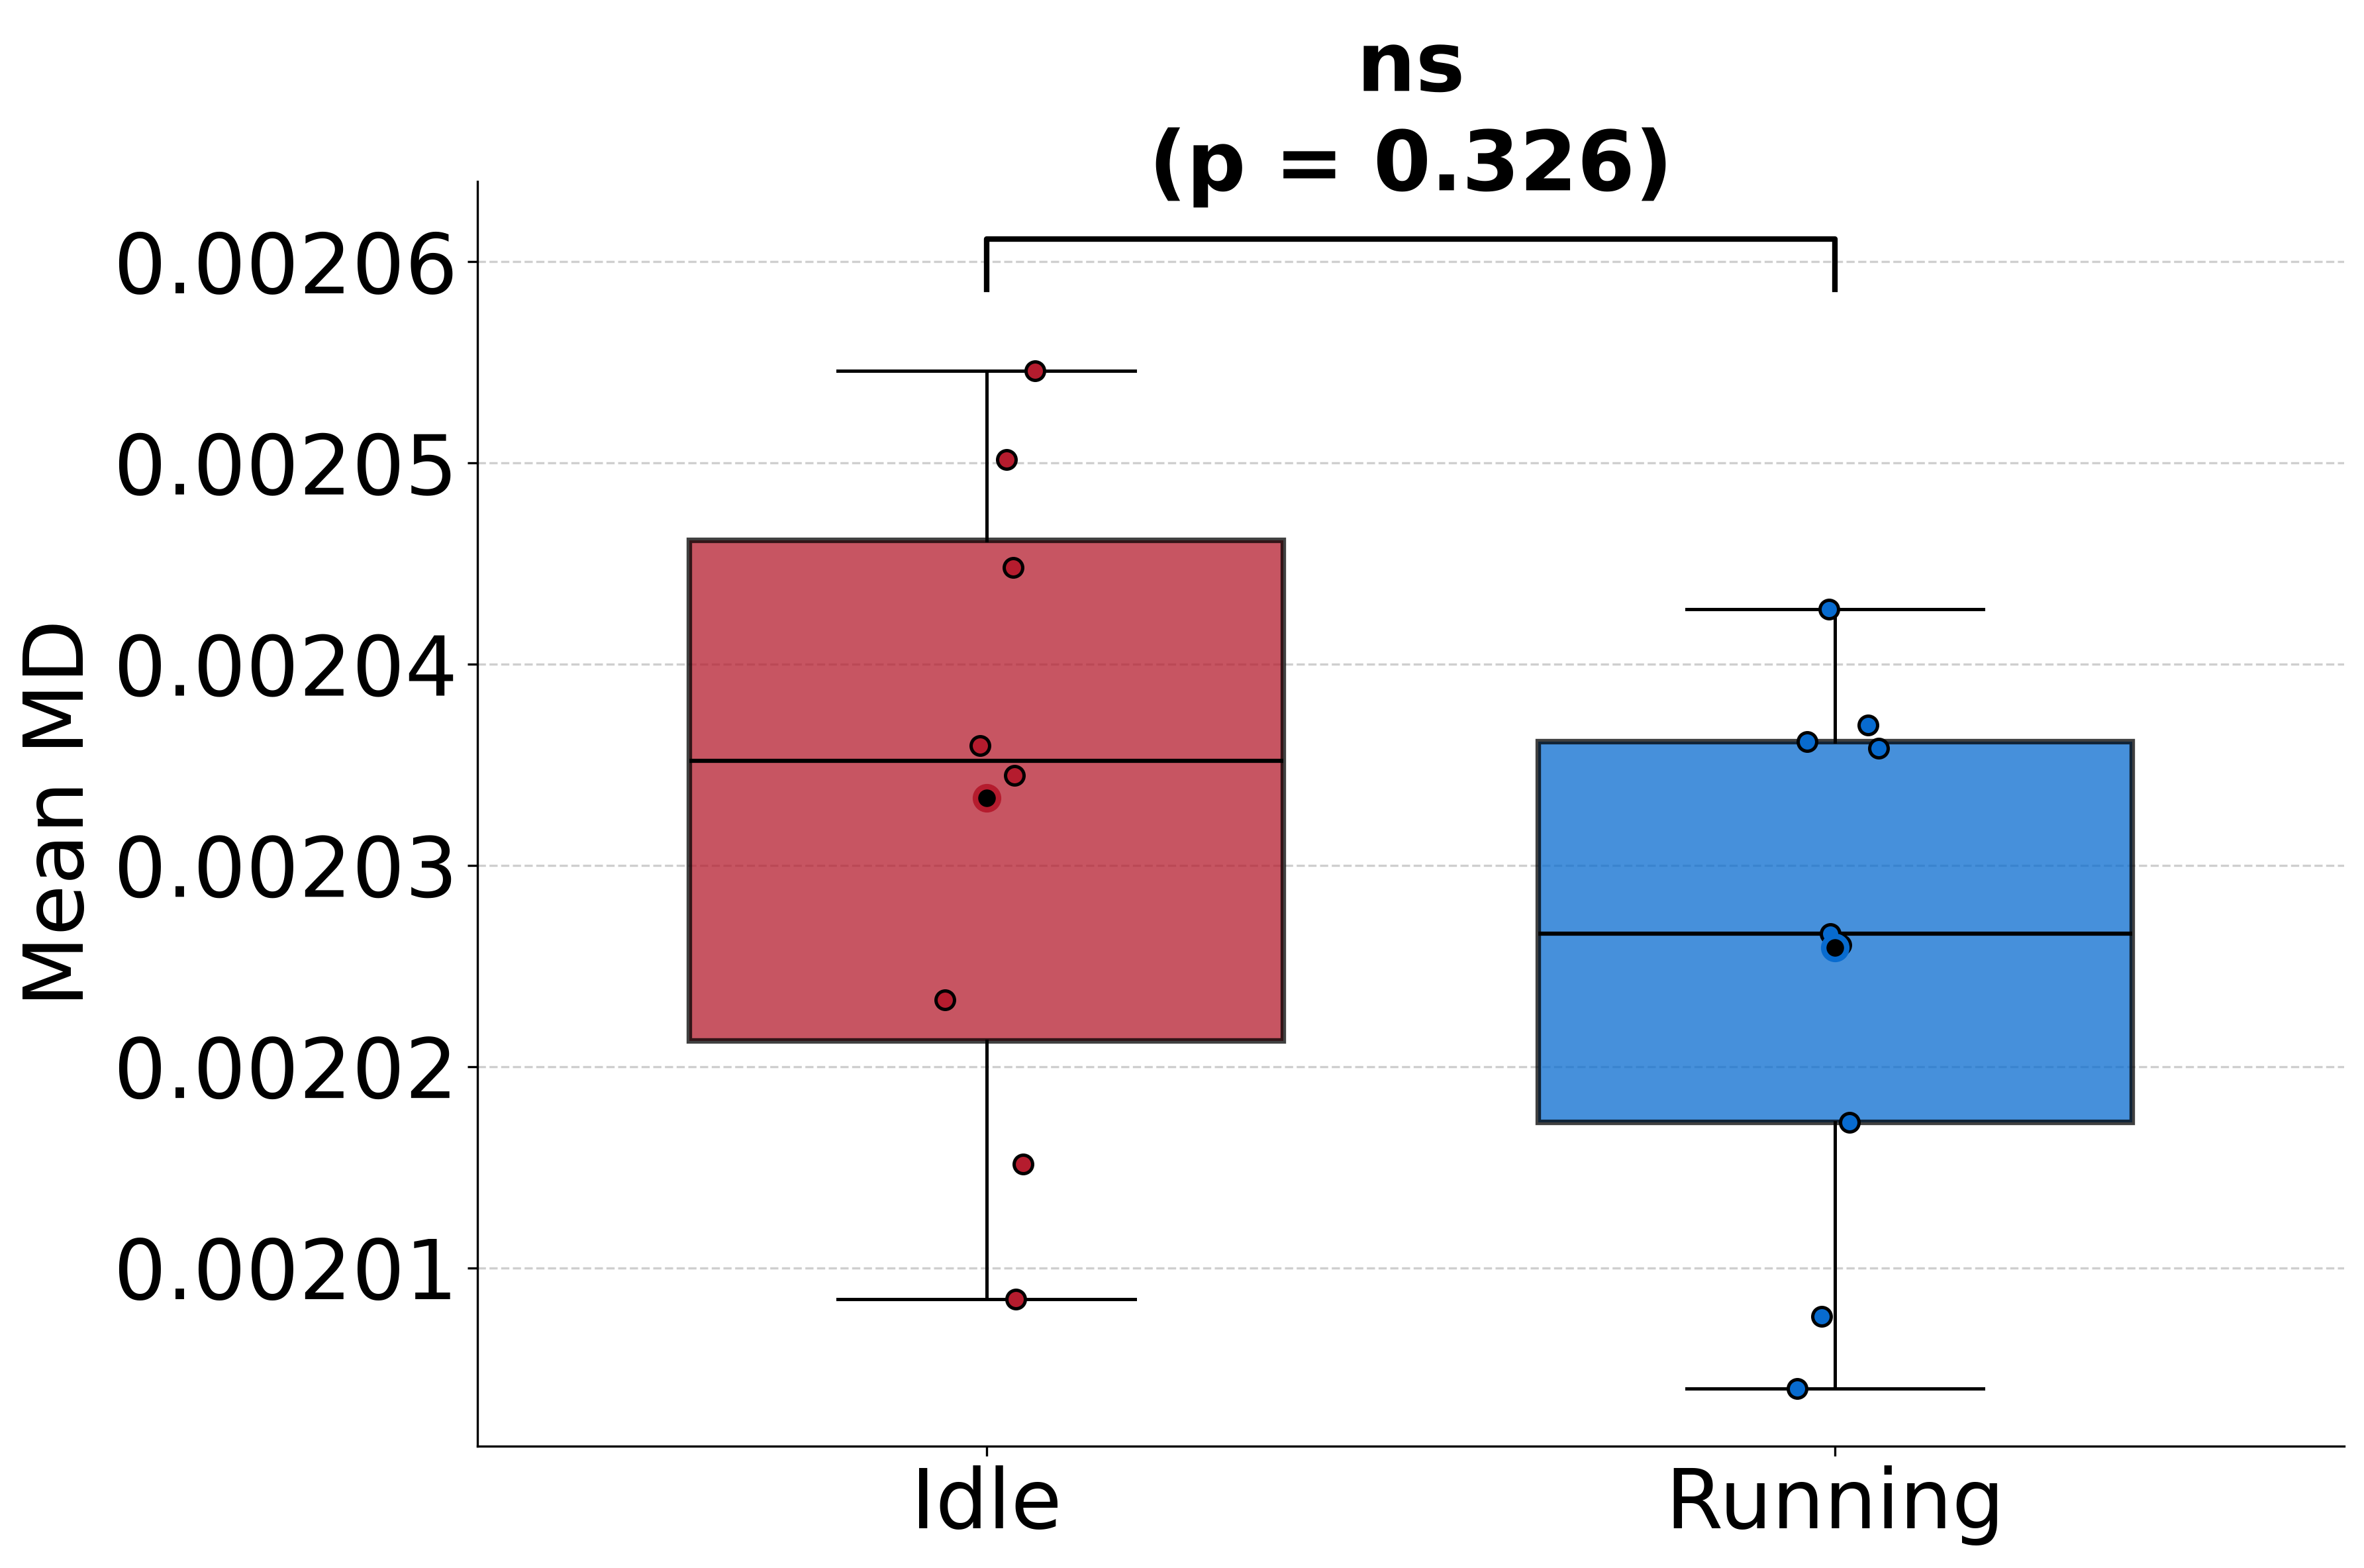

In [39]:
CONDITION_COLORS = {
    "Asterix_c": "#B51C2E",
    "Asterix_w": "#086BCF",
}


CONDITION_LABELS = {
    "Asterix_c": "Cold",
    "Asterix_w": "Warm",
}

FONTSIZE = 30
# ─────────────────────────────────────────────────────────────────
# GLOBAL MASK
# ─────────────────────────────────────────────────────────────────
mask_path = r"/home/malberti/wks14/temp/FF_DWI_Drift/script/Asterix_Obelix_Population_Template/Panoramix_Template_Tmean_mask.nii"
mask      = nib.load(mask_path).get_fdata().astype(bool)

# ─────────────────────────────────────────────────────────────────
# COLLECT — one mean MD per subject × session (global mask)
# ─────────────────────────────────────────────────────────────────
records = []

deriv_base = os.path.join(prj_path, "derivatives")

for cond, (sub_ids, ses) in CONDITIONS.items():
    for sid in sub_ids:
        sub_id  = f"sub-{sid:02d}"
        session = f"ses-{ses}"
        subjid  = f"{sub_id}_{session}"

        map_path = os.path.join(deriv_base, sub_id, session, "dwi", "index2TEMPLATE", "smooth", f"{subjid}_prep_{metric}2PANORAMIX-{kernel_size}.nii")

        img  = nib.load(map_path).get_fdata()
        vals = img[mask]
        vals = vals[(vals > 0) & (vals < THR)]

        records.append({
            "subject":   sub_id,
            "session":   session,
            "condition": cond,
            "MD":        np.mean(vals),
        })

df = pd.DataFrame(records)
print(f"\nTotal sessions collected: {len(df)}")
print(df.groupby("condition")["subject"].count().rename("n_sessions").to_string())

# ─────────────────────────────────────────────────────────────────
# AVERAGE ACROSS SESSIONS → one value per subject × condition
# ─────────────────────────────────────────────────────────────────
df_subj = (
    df.groupby(["subject", "condition"])["MD"]
    .mean()
    .reset_index()
)

cold = df_subj.loc[df_subj["condition"] == "Asterix_c", "MD"].values
warm = df_subj.loc[df_subj["condition"] == "Asterix_w", "MD"].values

print(f"\nCold  n={len(cold)}  mean={cold.mean():.6f}  std={cold.std():.6f}")
print(f"Warm  n={len(warm)}  mean={warm.mean():.6f}  std={warm.std():.6f}")

# ─────────────────────────────────────────────────────────────────
# T-TEST  (independent samples — between subjects)
# ─────────────────────────────────────────────────────────────────
t_stat, p_val = stats.ttest_ind(warm, cold, equal_var=True)  # Welch

print(f"\n── Independent-samples Welch t-test (Warm vs Cold) ──")
print(f"  t = {t_stat:.4f}")
print(f"  p = {p_val:.4f}")

# ─────────────────────────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8), dpi=300, facecolor="white")

conds  = ["Asterix_c", "Asterix_w"]
labels = [CONDITION_LABELS[c] for c in conds]
colors = [CONDITION_COLORS[c] for c in conds]
data   = [cold, warm]
x      = np.arange(len(conds))

# ── BOXPLOT ───────────────────────────────────────────────────────
parts = ax.boxplot(
    data,
    positions=x,
    widths=0.7,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=2),
    capprops=dict(linewidth=2),
    medianprops=dict(color="black", linewidth=1.5)
)

for patch, col in zip(parts["boxes"], colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)

for part in ["whiskers", "caps"]:
    for line in parts[part]:
        line.set_color("black")
        line.set_linewidth(1.2)

# ── JITTERED POINTS ──────────────────────────────────────────────
rng = np.random.default_rng(42)

for i, d in enumerate(data):
    if len(d) == 0:
        continue

    jitter = rng.uniform(-0.06, 0.06, size=len(d))

    ax.scatter(
        x[i] + jitter,
        d,
        color=colors[i],
        edgecolors="black",
        linewidths=1.2,
        s=45,
        zorder=3,
        alpha=1
    )

    ax.scatter(
        x[i],
        np.mean(d),
        color="black",
        edgecolors=colors[i],
        linewidths=2,
        s=70,
        zorder=4
    )

# ── SIGNIFICANCE BRACKET ─────────────────────────────────────────
y_min   = min(d.min() for d in data if len(d) > 0)
y_max   = max(d.max() for d in data if len(d) > 0)
y_range = y_max - y_min

y_annot = y_max + y_range * 0.08
y_tip   = y_annot + y_range * 0.05

ax.plot(
    [x[0], x[0], x[1], x[1]],
    [y_annot, y_tip, y_tip, y_annot],
    lw=2,
    color="black"
)

if   p_val < 0.001: stars = "***"
elif p_val < 0.01:  stars = "**"
elif p_val < 0.05:  stars = "*"
else:               stars = "ns"

p_label = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.3f}"

ax.text(
    (x[0] + x[1]) / 2,
    y_tip + y_range * 0.02,
    f"{stars}\n({p_label})",
    ha="center",
    va="bottom",
    fontsize=FONTSIZE,
    fontweight="bold"
)

# ── AXIS STYLE ────────────────────────────────────────────────────
ax.set_xlim(-0.6, 1.6)
ax.set_xticks(x)
ax.set_xticklabels(("Idle", "Running"), fontsize=FONTSIZE)
ax.tick_params(axis="y", labelsize=FONTSIZE)
ax.grid(True, axis="y", linestyle="--", alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylabel(f"Mean {metric}", fontsize=FONTSIZE)

plt.tight_layout()
plt.show()

### PLOTs ROIs 
----------------------------------


In [25]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from scipy import stats
import pandas as pd
import pingouin as pg

# ─────────────────────────────────────────────────────────────────
# COLLECT
# ─────────────────────────────────────────────────────────────────
values  = {region: defaultdict(list) for region in REGIONS_dMRI} #REGIONS_dMRI
records = []

deriv_base = os.path.join(prj_path, "derivatives")

REGION_COLORS = {
    "Anterior":  {"Asterix_c": "#058E4A", "Asterix_w": "#43C57E"},
    "Mid":       {"Asterix_c": "#B51C2E", "Asterix_w": "#E6906C"},
    "Posterior": {"Asterix_c": "#086BCF", "Asterix_w": "#6ABAE2"},
}


for cond, (sub_ids, ses) in CONDITIONS.items():
    for sid in sub_ids:
        sub_id = f"sub-{sid:02d}"
        session = f"ses-{ses}"
        subjid  = f"{sub_id}_{session}"

        # Run the ANOVA/plots on PANORAMIX and dMRI space 
        ## PANORAMIX
        map_path  = os.path.join(deriv_base, sub_id, session, "dwi", "index2TEMPLATE", "smooth", f"{subjid}_prep_{metric}2PANORAMIX-{kernel_size}.nii")
        masks_dir = os.path.join(deriv_base, sub_id, session, "dwi", "masks")

        ## dMRI space 
        map_path  = os.path.join(deriv_base, sub_id, session, "dwi", "index","Tensor", f"{subjid}_prep_{metric}.nii")

        if not os.path.exists(map_path):
            print(f"✗  Missing map: {map_path}")
            continue

        img = nib.load(map_path).get_fdata()

        for region, mask_stem in REGIONS_dMRI.items(): #REGIONS_dMRI
            ## PANORAMIX space
            mask_path = os.path.join(masks_dir, f"{subjid}_{mask_stem}.nii.gz")

            ## dMRI space 
            mask_path = os.path.join(masks_dir, f"{subjid}_{mask_stem}.nii.gz")


            mask = nib.load(mask_path).get_fdata().astype(bool)
            vals = img[mask]
            vals = vals[(vals > 0) & (vals < THR)]

            # 2*std filter
            upper_vals = (np.mean(vals)) + 1*(np.std(vals))
            lower_vals = (np.mean(vals)) - 1*(np.std(vals))

            vals = vals[(vals > lower_vals) & (vals < upper_vals)]
            records.append({
                "subject":   sub_id,
                "condition": cond,
                "ROI":       region,
                "MD":        np.mean(vals),
            })

# ── average across sessions per subject × condition × ROI ─────────
df_anova = pd.DataFrame(records)
print(f"Subjects: {df_anova['subject'].nunique()}")
print(df_anova.groupby(["condition", "ROI"])["subject"].count().to_string())

aov = pg.mixed_anova(
    data    = df_anova,
    dv      = "MD",
    within  = "ROI",
    between = "condition",
    subject = "subject",
)

display(aov)

Subjects: 17
condition  ROI      
Asterix_c  Anterior     8
           Mid          8
           Posterior    8
Asterix_w  Anterior     9
           Mid          9
           Posterior    9


,Source,SS,DF1,DF2,MS,F,p_unc,p_GG_corr,np2,eps,sphericity,W_spher,p_spher
0,condition,2.185515e-09,1,15,2.185515e-09,5.130574,3.874827e-02,NaN,0.254865,NaN,NaN,NaN,NaN
1,ROI,1.459648e-07,2,30,7.298241e-08,2519.447006,3.829311e-34,9.876731e-22,0.994082,0.57924,False,0.273601,0.00006
2,Interaction,5.376618e-11,2,30,2.688309e-11,0.928039,4.063818e-01,NaN,0.058264,NaN,NaN,NaN,NaN


In [33]:
# ─────────────────────────────────────────────────────────────────
# PLOT  (reads from df_anova)
# ─────────────────────────────────────────────────────────────────
cond_order = ["Asterix_c", "Asterix_w"]
x_pos      = np.arange(len(cond_order))
ID_SPLIT   = 48   # subjects with sub_id_num > ID_SPLIT get an 'x' marker

fig, axes = plt.subplots(1, 3, figsize=(22, 9), dpi=600, sharey=True, facecolor="white")

for ax, region in zip(axes, REGIONS_dMRI.keys()):

    # pull MD *and* sub_id_num together so markers can be split by ID
    data_region = [df_anova.loc[(df_anova["ROI"] == region) & (df_anova["condition"] == cond), ["MD", "subject"]]
        for cond in cond_order
    ]


    colors_region = [REGION_COLORS[region][cond] for cond in cond_order]

    for cond, d in zip(cond_order, data_region):
        print(f"  {region} | {cond} → n={len(d)}")

    parts = ax.boxplot([d["MD"].values for d in data_region], positions=x_pos, widths=0.5,
                       patch_artist=True,
                       showfliers=False,
                        boxprops=dict(linewidth=2),
                        whiskerprops=dict(linewidth=2),
                        capprops=dict(linewidth=2),
                       medianprops=dict(color="black", linewidth=2.5))

    for patch, col in zip(parts["boxes"], colors_region):
        patch.set_facecolor(col)
        patch.set_alpha(0.9)

    for part in ["whiskers", "caps"]:
        for line in parts[part]:
            line.set_color("black")
            line.set_linewidth(1.2)

    rng = np.random.default_rng(42)
    all_y = []
    for i, (d, col) in enumerate(zip(data_region, colors_region)):
        if len(d) == 0:
            continue

        subject_num = d["subject"].str.extract(r"(\d+)")[0].astype(int)

        low_ids = d[subject_num <= ID_SPLIT]
        high_ids = d[subject_num > ID_SPLIT]

        for subset, marker in [(low_ids, "o"), (high_ids, "x")]:
            if len(subset) == 0:
                continue
            jitter = rng.uniform(-0.06, 0.06, size=len(subset))
            ax.scatter(x_pos[i] + jitter, subset["MD"].values, color=col if marker == "o" else "black" , marker=marker,
                       edgecolors="black",
                       linewidths=1.5, s=40, zorder=3, alpha=0.75)

        ax.scatter(x_pos[i], d["MD"].mean(), color="black", edgecolors=col, s=60, zorder=4, linewidths=2)
        all_y.extend(d["MD"].tolist())

    # per-region Welch t-test
    c_vals, w_vals = [d["MD"].values for d in data_region]
    if len(c_vals) > 1 and len(w_vals) > 1:
        _, p = stats.ttest_ind(w_vals, c_vals, equal_var=False)
    else:
        p = 1.0

    all_vals  = np.concatenate([d["MD"].values for d in data_region]) if any(len(d) > 0 for d in data_region) else np.array([0])
    y_min_r   = all_vals.min()
    y_max_r   = all_vals.max()
    y_range_r = y_max_r - y_min_r
    y_annot   = y_max_r + y_range_r * 0.08
    y_tip     = y_annot + y_range_r * 0.05

    ax.plot([x_pos[0], x_pos[0], x_pos[1], x_pos[1]], [y_annot, y_tip, y_tip, y_annot], lw=2, color="black")

    if   p < 0.001: sig = "***"
    elif p < 0.01:  sig = "**"
    elif p < 0.05:  sig = "*"
    else:           sig = f"ns"

    ax.text((x_pos[0] + x_pos[1]) / 2, y_tip + y_range_r * 0.02, f"{sig}", ha="center", va="bottom", fontsize=40)

    ax.set_title(f"{region}\n", fontsize=30, fontweight="bold", pad=55)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(["Idle", "Running"], fontsize=30)
    ax.set_xlim(-0.6, 1.6)
    ax.tick_params(axis="y", labelsize=30 )
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel(f"Mean MD", fontsize=30)

# ── global condition bracket spanning all subplots ────────────────
fig.canvas.draw()
inv = fig.transFigure.inverted()

x0 = inv.transform(axes[0].transData.transform((x_pos[0], 0)))[0]
x1 = inv.transform(axes[2].transData.transform((x_pos[1], 0)))[0]

y_top  = axes[0].get_position().y1
y_bar  = y_top + 0.10
y_tick = y_bar - 0.015

fig.lines.append(plt.Line2D([x0, x1], [y_bar, y_bar],
    transform=fig.transFigure, color="black", linewidth=2))
for xpt in [x0, x1]:
    fig.lines.append(plt.Line2D([xpt, xpt], [y_tick, y_bar],
        transform=fig.transFigure, color="black", linewidth=2))

# ── pull condition p-value from the mixed ANOVA result ───────────
p_condition = float(aov.loc[aov["Source"] == "condition", "p_unc"].values[0])

if   p_condition < 0.001: cond_stars = "***"
elif p_condition < 0.01:  cond_stars = "**"
elif p_condition < 0.05:  cond_stars = "*"
else:                     cond_stars = "ns"

fig.text((x0 + x1) / 2, y_bar + 0.025,
         f"Condition main effect: {cond_stars}  (p = {p_condition:.3f})\n",
         ha="center", va="bottom", fontsize=40, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

  Anterior | Asterix_c → n=8
  Anterior | Asterix_w → n=9
  Mid | Asterix_c → n=8
  Mid | Asterix_w → n=9
  Posterior | Asterix_c → n=8
  Posterior | Asterix_w → n=9


### Plot ROIs and color/order participant by sub ID / time 
-------------------------------------------------------------

In [ ]:
# ── compute global subject-number range for consistent color scale across panels ──
all_subject_nums = df_anova["subject"].str.extract(r"(\d+)")[0].astype(int)
cmap = plt.cm.Set1   # reversed: bright = low subject number, dark = high
norm = plt.Normalize(vmin=all_subject_nums.min(), vmax=all_subject_nums.max())

def red_to_blue(n=len(subject_num)):
    red  = np.array([255, 0, 0])
    blue = np.array([0, 0, 255])
    colors = []
    for t in np.linspace(0, 1, n):
        rgb = (1 - t) * red + t * blue
        colors.append('#%02X%02X%02X' % tuple(rgb.astype(int)))
    return colors

fig, axes = plt.subplots(1, 3, figsize=(22, 9), dpi=300, sharey=True, facecolor="white")

for ax, region in zip(axes, REGIONS_dMRI.keys()):

    data_region = [df_anova.loc[(df_anova["ROI"] == region) & (df_anova["condition"] == cond), ["MD", "subject"]]
        for cond in cond_order
    ]

    colors_region = [REGION_COLORS[region][cond] for cond in cond_order]

    for cond, d in zip(cond_order, data_region):
        print(f"  {region} | {cond} → n={len(d)}")

    parts = ax.boxplot([d["MD"].values for d in data_region], positions=x_pos, widths=0.5, 
                       patch_artist=True,
                       showfliers=False,
                        boxprops=dict(linewidth=2,alpha=0.3),
                        whiskerprops=dict(linewidth=2,alpha=0.3),
                        capprops=dict(linewidth=2,alpha=0.3),
                       medianprops=dict(color="black", linewidth=2.5))

    for patch, col in zip(parts["boxes"], colors_region):
        patch.set_facecolor(col)
        patch.set_alpha(0.3)

    for part in ["whiskers", "caps"]:
        for line in parts[part]:
            line.set_color("black")
            line.set_linewidth(1.2)

    rng = np.random.default_rng(42)
    all_y = []


    for i, (d, col) in enumerate(zip(data_region, colors_region)):
        if len(d) == 0:
            continue

        subject_num = d["subject"].str.extract(r"(\d+)")[0].astype(int)
        cmap = red_to_blue(len(subject_num))
        jitter = rng.uniform(-0.06, 0.06, size=len(d))
        ax.scatter(x_pos[i] + jitter, d["MD"].values, color=cmap, marker="o", edgecolors="black", linewidths=1.5, s=40, zorder=3, alpha=0.85)

        ax.scatter(x_pos[i], d["MD"].mean(), color="black", edgecolors=col, s=60, zorder=4, linewidths=2)
        all_y.extend(d["MD"].tolist())

    # per-region Welch t-test
    c_vals, w_vals = [d["MD"].values for d in data_region]
    if len(c_vals) > 1 and len(w_vals) > 1:
        _, p = stats.ttest_ind(w_vals, c_vals, equal_var=False)
    else:
        p = 1.0

    all_vals  = np.concatenate([d["MD"].values for d in data_region]) if any(len(d) > 0 for d in data_region) else np.array([0])
    y_min_r   = all_vals.min()
    y_max_r   = all_vals.max()
    y_range_r = y_max_r - y_min_r
    y_annot   = y_max_r + y_range_r * 0.08
    y_tip     = y_annot + y_range_r * 0.05

    ax.plot([x_pos[0], x_pos[0], x_pos[1], x_pos[1]], [y_annot, y_tip, y_tip, y_annot], lw=2, color="black")

    if   p < 0.001: sig = "***"
    elif p < 0.01:  sig = "**"
    elif p < 0.05:  sig = "*"
    else:           sig = "ns"

    ax.text((x_pos[0] + x_pos[1]) / 2, y_tip + y_range_r * 0.02, f"{sig}", ha="center", va="bottom", fontsize=30)

    ax.set_title(f"{region}\n", fontsize=30, fontweight="bold", pad=55)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(["Cold", "Warmed-up"], fontsize=30)
    ax.set_xlim(-0.6, 1.6)
    ax.tick_params(axis="y", labelsize=26)
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel(f"", fontsize=30)



## Indivdual Shells analysis 
------------------------------

### Plot B1000/B0 average signal


### PLOTs: Make histogram out of voxels intesity distribution
The idea behind this block is to test if there are significant differences in values distribution between the two conditions. Te blocks below


[PROC] sub-16_ses-01  (Asterix | Asterix_c)
[PROC] sub-17_ses-01  (Asterix | Asterix_c)
[PROC] sub-20_ses-01  (Asterix | Asterix_c)
[PROC] sub-21_ses-01  (Asterix | Asterix_c)
[PROC] sub-25_ses-01  (Asterix | Asterix_c)
[PROC] sub-26_ses-01  (Asterix | Asterix_c)
[PROC] sub-29_ses-01  (Asterix | Asterix_c)
[PROC] sub-30_ses-01  (Asterix | Asterix_c)
[PROC] sub-32_ses-01  (Asterix | Asterix_c)
[PROC] sub-15_ses-13  (Asterix | Asterix_w)
[PROC] sub-18_ses-13  (Asterix | Asterix_w)
[PROC] sub-19_ses-13  (Asterix | Asterix_w)
[PROC] sub-22_ses-13  (Asterix | Asterix_w)
[PROC] sub-23_ses-13  (Asterix | Asterix_w)
[PROC] sub-24_ses-13  (Asterix | Asterix_w)
[PROC] sub-27_ses-13  (Asterix | Asterix_w)
[PROC] sub-28_ses-13  (Asterix | Asterix_w)
[PROC] sub-31_ses-13  (Asterix | Asterix_w)


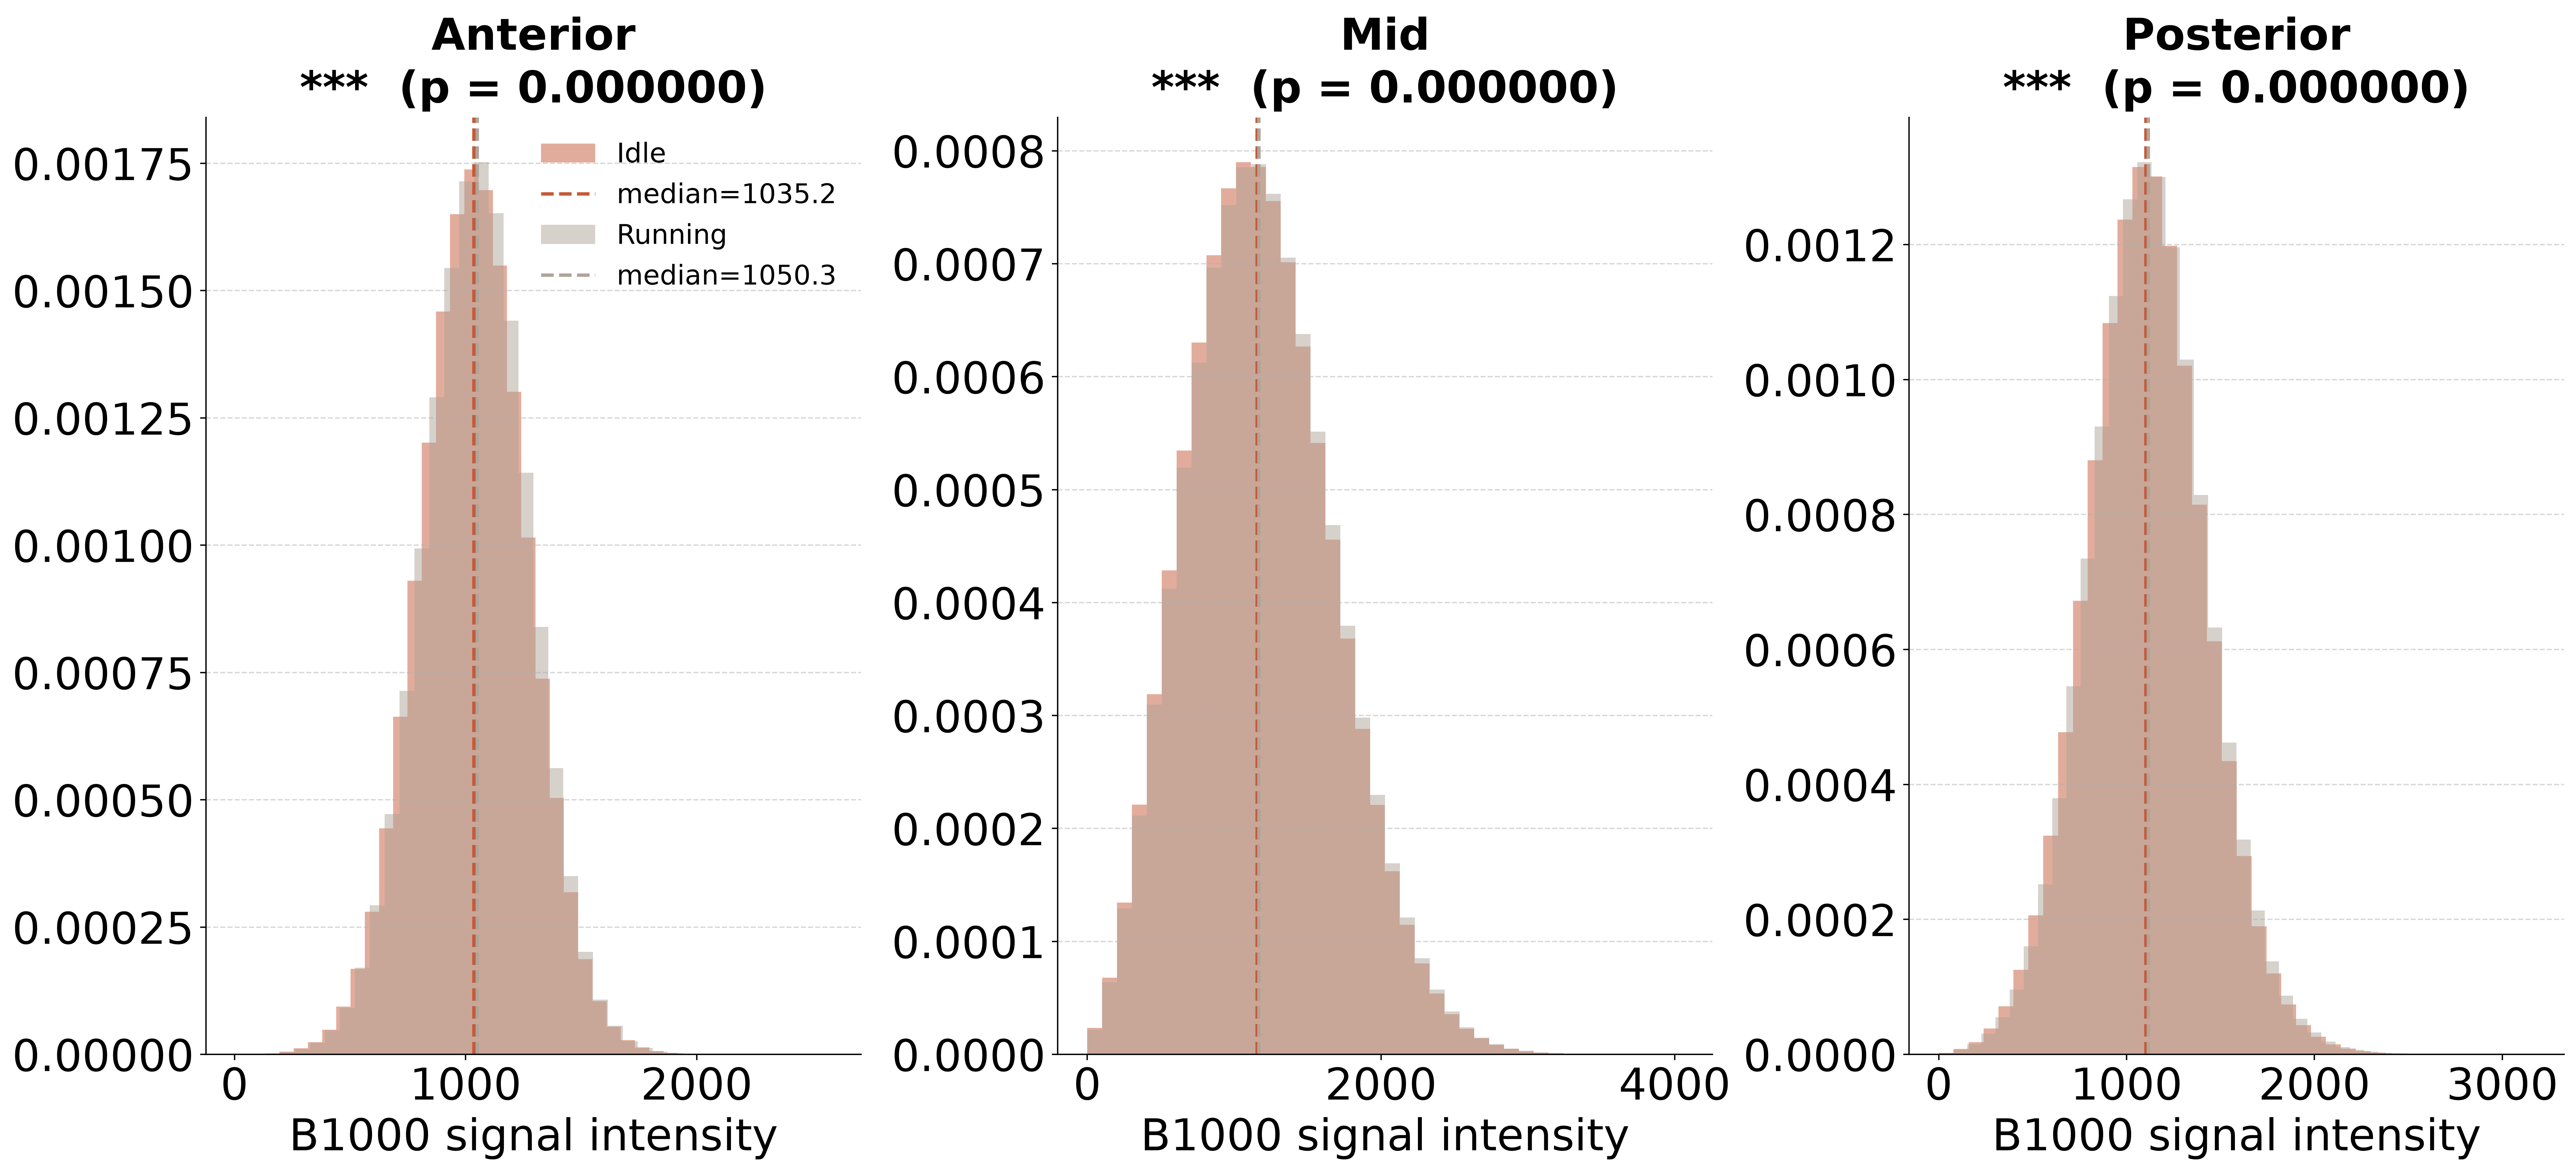

In [42]:
B0_THRESH  = 50        # bval < 50   → B0
B1000_LOW  = 800       # 800 < bval < 1200 → B1000
B1000_HIGH = 1200

BVALs = ["b1000"]     # which shell's voxel intensities to plot: "b0" or "b1000"
VAL_MIN, VAL_MAX = 0, 5000   # crude physiological range filter — adjust to your signal scale

CONDITION_COLORS = {
    "Asterix_c": ("#B51C2E", "Cold"),
    "Asterix_w": ("#086BCF", "Warmed-up"),
}

CONDITION_COLORS = {
    "Asterix_c": ("#C65A3A","Idle"),
    "Asterix_w":("#AFA498","Running"),
}

# ─────────────────────────────────────────────────────────────────
# COLLECT — stack all voxels per condition × ROI
# ─────────────────────────────────────────────────────────────────
all_voxels = {
    region: {cond: [] for cond in CONDITIONS}
    for region in REGIONS_dMRI
}

for BVAL_SELECT in BVALs: 
    for condition, (sub_ids, ses) in CONDITIONS.items():
        for sid in sub_ids:
            pid    = f"sub-{sid:02d}"
            subjid = f"{pid}_ses-{ses}"

            base      = os.path.join(prj_path, "derivatives", pid, f"ses-{ses}", "dwi")
            eddy_path = os.path.join(base, "eddy")
            prep_path = os.path.join(base, "prep")
            masks_dir = os.path.join(base, "masks")

           # dwi_path  = os.path.join(eddy_path, f"{subjid}_eddy_corrected.nii")
            dwi_path  = os.path.join(eddy_path, f"{subjid}_eddy_corrected.nii")
            bval_path = os.path.join(prep_path, f"{subjid}_dir-PA-AP_part-mag_dwi.bval")

            if not (os.path.exists(dwi_path) and os.path.exists(bval_path)):
                print(f"✗  MISSING data for {subjid}, skipping")
                continue

            print(f"[PROC] {subjid}  (Asterix | {condition})")

            for region, mask_stem in REGIONS_dMRI.items():
                mask_path = os.path.join(masks_dir, f"{subjid}_{mask_stem}.nii.gz")

                #subprocess.run(f"fsleyes {dwi_path} {mask_path}", shell=True)

                if BVAL_SELECT == "b0":
                    masked, _ = extract_volumes_masked_no_smoothing(dwi_path, bval_path, mask_path, bval_low=0, bval_high=B0_THRESH)
                else:
                    masked, _ = extract_volumes_masked_no_smoothing(dwi_path, bval_path, mask_path, bval_low=B1000_LOW, bval_high=B1000_HIGH)


                vals = masked.flatten()   # all voxels × all volumes at this shell
                vals = vals[(vals > 0)]
                all_voxels[region][condition].extend(vals.tolist())

    # ─────────────────────────────────────────────────────────────────
    # PLOT — one panel per ROI, overlapping histograms per condition
    # ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, len(REGIONS_dMRI), figsize=(25, 10), dpi=400, facecolor="white")

    for ax, region in zip(axes, REGIONS_dMRI):
        for cond, (col, label) in CONDITION_COLORS.items():
            vals = np.array(all_voxels[region][cond])
            if len(vals) == 0:
                continue
            ax.hist(vals, bins=40, color=col, alpha=0.5,
                    label=label, density=True, edgecolor="none")
            ax.axvline(np.median(vals), color=col, linewidth=2, linestyle="--",
                        label=f"median={np.median(vals):.1f}")

        # t-test on voxel distributions
        v0 = np.array(all_voxels[region]["Asterix_c"])
        v1 = np.array(all_voxels[region]["Asterix_w"])
        if len(v0) > 1 and len(v1) > 1:
            _, p = stats.ks_2samp(v0, v1, method="asymp", )
            sig     = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            p_label = f"p = {p:3f}"
            ax.set_title(f"{region}\n{sig}  ({p_label})", fontsize=26, fontweight="bold")
        else:
            ax.set_title(region, fontsize=30, fontweight="bold")

        ax.set_xlabel(f"{BVAL_SELECT.upper()} signal intensity", fontsize=26)
        ax.set_ylabel("", fontsize=26)
        ax.tick_params(axis="y", labelsize=26)
        ax.tick_params(axis="x", labelsize=26)
        ax.grid(True, axis="y", linestyle="--", alpha=0.5)
        ax.spines[["top", "right"]].set_visible(False)

    axes[0].legend(fontsize=16, loc="upper right", frameon=False)
    plt.subplots_adjust(top=0.88, wspace=0.3)
    plt.show()

In [ ]:
v0 = np.array(all_voxels[region]["Asterix_c"])
v1 = np.array(all_voxels[region]["Asterix_w"])

results = stats.ks_2samp(v0, v1)

## Compute statistics: 
----------------------
#### two-sample Kolmogorov-Smirnov: 

With this code i need to check if the distribution of values differ significantly between conditions: 
Performs the two-sample Kolmogorov-Smirnov test for goodness of fit. This test compares the underlying continuous distributions F(x) and G(x) of two independent samples. 
See Notes for a description of the available null and alternative hypotheses.
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_2samp.html

In [ ]:
B0_THRESH  = 50        # bval < 50   → B0
B1000_LOW  = 800       # 800 < bval < 1200 → B1000
B1000_HIGH = 1200

BVALs = ["b0", "b1000"]     # which shell's voxel intensities to plot: "b0" or "b1000"
VAL_MIN, VAL_MAX = 0, 5000   # crude physiological range filter — adjust to your signal scale

CONDITION_COLORS = {
    "Asterix_c": ("#B51C2E", "Cold"),
    "Asterix_w": ("#086BCF", "Warmed-up"),
}

# ─────────────────────────────────────────────────────────────────
# COLLECT — stack all voxels per condition × ROI
# ─────────────────────────────────────────────────────────────────
all_voxels = {
    region: {cond: [] for cond in CONDITIONS}
    for region in REGIONS_dMRI
}

for BVAL_SELECT in BVALs: 
    for condition, (sub_ids, ses) in CONDITIONS.items():
        for sid in sub_ids:
            pid    = f"sub-{sid:02d}"
            subjid = f"{pid}_ses-{ses}"

            base      = os.path.join(prj_path, "derivatives", pid, f"ses-{ses}", "dwi")
            eddy_path = os.path.join(base, "eddy")
            prep_path = os.path.join(base, "prep")
            masks_dir = os.path.join(base, "masks")

            dwi_path  = os.path.join(eddy_path, f"{subjid}_eddy_corrected.nii")
            bval_path = os.path.join(prep_path, f"{subjid}_dir-PA-AP_part-mag_dwi.bval")

            if not (os.path.exists(dwi_path) and os.path.exists(bval_path)):
                print(f"✗  MISSING data for {subjid}, skipping")
                continue

            print(f"[PROC] {subjid}  (Asterix | {condition})")

            for region, mask_stem in REGIONS_dMRI.items():
                mask_path = os.path.join(masks_dir, f"{subjid}_{mask_stem}.nii.gz")
                if not os.path.exists(mask_path):
                    print(f"✗  Missing mask: {mask_path}")
                    continue

                if BVAL_SELECT == "b0":
                    masked, _ = extract_volumes_masked( dwi_path, bval_path, mask_path, bval_low=0, bval_high=B0_THRESH)
                else:
                    masked, _ = extract_volumes_masked(dwi_path, bval_path, mask_path, bval_low=B1000_LOW, bval_high=B1000_HIGH)

                if masked is None:
                    continue

                vals = masked.flatten()   # all voxels × all volumes at this shell
                vals = vals[(vals > 0)]
                all_voxels[region][condition].extend(vals.tolist())

# Plot B0-B1 map& flip angle
----------------------------

1) First, create the ROIs, flip angle etc.. have a differnt size/space, i can't use the ROIs from the diffusion
2) Compute plots and Histograms 

In [18]:
import os
import subprocess
import numpy as np
import nibabel as nib
import glob, re
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import stats


# ===========================================================================
# CONFIGURATION
# ===========================================================================
# ── Input ────────────────────────────────────────────────────────────────
# I left Obelix out from this pipeline
Asterix_c = [16, 17, 20, 21, 25, 26, 29, 30, 32, 33, 34, 35, 36, 39, 40, 44]   # ses-01
Asterix_w = [15, 18, 19, 22, 23, 24, 27, 28, 31, 37, 38, 41, 42, 43, 45]       # ses-13

## SET WORKING DIRECTORY
prj_path = r"/home/malberti/wks14/temp/FF_DWI_Drift"   # main BIDS path
project  = "sub-"       # common prefix for participant folders/files
script   = r"/home/malberti/wks14/temp/FF_DWI_Drift/Script"
PANORAMIX = "/home/malberti/Unix_Folders/Asterix_Obelix_Population_Template/Panoramix_Template_Tmean.nii"
metric    = "MD"

# Default cube size (px, py, pz)
DEFAULT_CUBE_SIZE = (10, 10, 10)

# Default per-ROI offsets from the auto-computed centres.
DEFAULT_OFFSETS = {
    "ant":  {"dx": 0, "dy": 23,  "dz":  5},   # anterior  (BrBG)
    "mid":  {"dx": 0, "dy": 15,  "dz": -15},  # middle    (RdGy)
    "post": {"dx": 0, "dy": 13,  "dz":  5},   # posterior (Blues_r)
}

# condition -> (subject numbers, session code)
conditions = {
    "Asterix_c": (Asterix_c, "01"),
    "Asterix_w": (Asterix_w, "13"),
}

approve = True



def make_2d_affine(img):
    """
    Return a valid 4x4 affine for a 2D NIfTI slice.
    If the z-column is zero (degenerate 2D affine), replace it with the
    unit normal to the image plane (cross-product of x and y axes), scaled
    to 1 mm, so the matrix stays invertible and all outputs share one space.
    """
    A = img.affine.copy()
    if np.allclose(A[:3, 2], 0):
        normal = np.cross(A[:3, 0], A[:3, 1])
        norm   = np.linalg.norm(normal)
        if norm > 0:
            A[:3, 2] = normal / norm
    return A


def make_2d_header(img):
    """Return a header with non-zero pixdim[3] (z voxel size)."""
    h = img.header.copy()
    if h['pixdim'][3] == 0:
        h['pixdim'][3] = 1.0
    return h


def save_nifti(data, affine, header, path):
    """Save a NIfTI, enforcing consistent qform/sform."""
    img = nib.Nifti1Image(data.astype(np.uint8), affine, header)
    img.set_qform(affine, code=1)
    img.set_sform(affine, code=1)
    nib.save(img, path)


def build_masks(mask, offsets, cube_size):

    original_2d = False

    if mask.ndim == 2:
        original_2d = True
        mask = mask[:, :, np.newaxis]

    X, Y, Z = mask.shape

    if original_2d:
        px, py = cube_size[:2]
        pz = 1
    else:
        px, py, pz = cube_size

    x_center = X // 2 - px // 2
    y_center = Y // 2 - py // 2
    z_center = Z // 2 - pz // 2

    starts = {
        "ant": (  # orange
            x_center + 12 + offsets["ant"]["dx"],
            y_center - 12 + offsets["ant"]["dy"],
            z_center + offsets["ant"]["dz"],
        ),
        "mid": (  # yellow
            x_center + offsets["mid"]["dx"],
            y_center - 20 + offsets["mid"]["dy"],
            z_center + offsets["mid"]["dz"],
        ),
        "post": (  # magenta
            x_center -15 + offsets["post"]["dx"],
            y_center -2 + offsets["post"]["dy"],
            z_center + 10 + offsets["post"]["dz"],
        ),
    }

    masks = {}

    for name, (xs, ys, zs) in starts.items():

        roi = np.zeros_like(mask, dtype=np.uint8)

        # clamp indices to valid range
        xs = max(0, min(xs, X - px))
        ys = max(0, min(ys, Y - py))
        zs = max(0, min(zs, Z - pz))

        roi[xs:xs + px, ys:ys + py, zs:zs + pz] = 1

        if original_2d:
            roi = roi[:, :, 0]

        masks[name] = roi

    return masks, starts


def save_tmp_masks(masks, affine, header, tmp_dir):
    os.makedirs(tmp_dir, exist_ok=True)
    paths = {}
    for key, arr in masks.items():
        if arr.ndim == 2:
            arr = arr[:, :, np.newaxis]
        path = os.path.join(tmp_dir, f"_tmp_cube_{key}.nii.gz")
        save_nifti(arr, affine, header, path)
        paths[key] = path
    return paths


def open_fsleyes(ref_path, mask_paths):
    cmd = [
        "fsleyes",
        ref_path,           "-cm", "greyscale",
        mask_paths["ant"],  "-cm", "copper",
        mask_paths["mid"],  "-cm", "red-yellow",
        mask_paths["post"], "-cm", "cool",
    ]
    print("\n  Opening FSLeyes … close the window when done.\n")
    subprocess.run(cmd)

In [44]:
# ===========================================================================
# MAIN LOOP
# ===========================================================================
label_map = {"ant": "anterior", "mid": "mid", "post": "posterior"}

for condition, (sub_ids, ses) in conditions.items():
    for sid in sub_ids:
        pid    = f"sub-{sid:02d}"          # e.g. "sub-16"
        subjid = f"{pid}_ses-{ses}"        # e.g. "sub-16_ses-01"

        derivatives = r"/home/malberti/Unix_Folders/ESMRMB2026_Manfredi"  #os.path.join(prj_path, "derivatives")
        base     = os.path.join(derivatives, pid, f"ses-{ses}", "twix")
        mask_dir = os.path.join(base, "mask_B1-space")
        tmp_dir  = os.path.join(mask_dir, "_tmp_masks")
        os.makedirs(base,     exist_ok=True)
        os.makedirs(mask_dir, exist_ok=True)
        os.makedirs(tmp_dir,  exist_ok=True)

        alpha_files = sorted(glob.glob(os.path.join(base, f"{subjid}_tfl_map-sag_*_b1.nii*")))  # Transmit eff. map dB0.nii

        if len(alpha_files) == 0:
            print(f"WARNING: no tfl_map-cor alpha files for {subjid} | {alpha_files}")
            continue

        for map_IMG in alpha_files:
            print(f"\nProcessing: {map_IMG}")

            img  = nib.load(map_IMG)
            data = img.get_fdata()

            # ── consistent affine/header for all 2D outputs ───────────
            affine = make_2d_affine(img)
            header = make_2d_header(img)

            # ── whole-brain binary mask ────────────────────────────────
            mask     = ((data > 0) & (data < 110)).astype(np.uint8)
            mask_out = mask[:, :, np.newaxis] if mask.ndim == 2 else mask

            # NOTE: mask_IMG was referenced but never defined in the
            # original script. Derived here from the source map filename
            # (strips .nii/.nii.gz and appends "_MASK_whole.nii.gz") -
            # adjust the suffix below if you use a different convention.
            map_base = os.path.basename(map_IMG)
            for ext in (".nii.gz", ".nii"):
                if map_base.endswith(ext):
                    map_base = map_base[:-len(ext)]
                    break
            mask_IMG = os.path.join(mask_dir, f"{map_base}_MASK_whole.nii.gz")
            save_nifti(mask_out, affine, header, mask_IMG)
            # print(f"Saved: {mask_IMG}")

            # ── greyscale reference for FSLeyes ────────────────────────
            ref_tmp_path = os.path.join(tmp_dir, f"_tmp_ref_{subjid}.nii.gz")
            ref_data     = data[:, :, np.newaxis] if data.ndim == 2 else data
            img_ref      = nib.Nifti1Image(ref_data, affine, header)
            img_ref.set_qform(affine, code=1)
            img_ref.set_sform(affine, code=1)
            nib.save(img_ref, ref_tmp_path)

            # ── ROI loop ────────────────────────────────────────────────
            offsets   = {k: dict(v) for k, v in DEFAULT_OFFSETS.items()}
            cube_size = DEFAULT_CUBE_SIZE
            approved  = False

            print(f"\n{'='*60}")
            print(f"  Subject: {subjid}")
            print(f"{'='*60}")

            while not approved:
                masks, starts = build_masks(mask, offsets, cube_size)
                mask_paths    = save_tmp_masks(masks, affine, header, tmp_dir)

                print("\n  Current ROI starts (voxel coords):")
                for roi, s in starts.items():
                    print(f"    {roi:4s}  x={s[0]:4d}  y={s[1]:4d}  z={s[2]:4d}")

                open_fsleyes(ref_tmp_path, mask_paths)
                approved = True

            # ── save final masks ───────────────────────────────────────
            for key, arr in masks.items():
                arr_out = arr[:, :, np.newaxis] if arr.ndim == 2 else arr
                fname   = f"{subjid}_tfl-cor_MASK_{label_map[key]}_b1.nii.gz"
                save_nifti(arr_out, affine, header, os.path.join(mask_dir, fname))
                print(f"  Saved → {fname}")

            # ── clean up tmp ────────────────────────────────────────────
            for p in mask_paths.values():
                os.remove(p)
            os.remove(ref_tmp_path)

            print(f"\n  ✓ {subjid} done.\n")

NameError: name 'glob' is not defined

## PLOTs 
-------------------

In [43]:
AXES = "sag"

# Mask filenames now produced by the build script look like:
#   {subjid}_tfl-cor_MASK_anterior_b1.nii.gz
# (region label + trailing "_b1"). Built here from AXES so it stays
# in sync if you later also generate "tfl-tra_..." masks.
REGIONS = {
    "Anterior":  f"tfl-{AXES}_MASK_anterior_b1",
    "Mid":       f"tfl-{AXES}_MASK_mid_b1",
    "Posterior": f"tfl-{AXES}_MASK_posterior_b1",
}

REGION_COLORS = {
    "Anterior":  {"Asterix_c": "#058E4A", "Asterix_w": "#43C57E"},
    "Mid":       {"Asterix_c": "#B51C2E", "Asterix_w": "#E6906C"},
    "Posterior": {"Asterix_c": "#086BCF", "Asterix_w": "#6ABAE2"},
}


# ─────────────────────────────────────────────────────────────────
# COLLECT — stack all voxels per condition × ROI
# ─────────────────────────────────────────────────────────────────
all_voxels = {
    region: {"Asterix_c": [], "Asterix_w": []}
    for region in REGIONS
}

for condition, (sub_ids, ses) in conditions.items():
    for sid in sub_ids:
        pid    = f"sub-{sid:02d}"          # e.g. "sub-16"
        subjid = f"{pid}_ses-{ses}"        # e.g. "sub-16_ses-01"

        derivatives = r"/home/malberti/Unix_Folders/ESMRMB2026_Manfredi"  #os.path.join(prj_path, "derivatives")
        base     = os.path.join(derivatives, pid, f"ses-{ses}", "twix")
        mask_dir = os.path.join(base, "mask_B1-space")

        alpha_files = sorted(glob.glob(os.path.join(base, f"{subjid}_tfl_map-sag_*_b1.nii"))) 

        for map_IMG in alpha_files:
            img  = nib.load(map_IMG).get_fdata()
            data = img[:, :, 0] if img.ndim == 3 else img

            for region, mask_stem in REGIONS.items():
                mask_path = os.path.join(mask_dir, f"{subjid}_{mask_stem}.nii.gz")
                if not os.path.exists(mask_path):
                    continue
                mask_data = nib.load(mask_path).get_fdata()
                mask_2d   = mask_data[:, :, 0] if mask_data.ndim == 3 else mask_data

                vals = data[mask_2d.astype(bool)]
                vals = vals[(vals > 0) & (vals < 110)]
                all_voxels[region][condition].extend(vals.tolist())

# ─────────────────────────────────────────────────────────────────
# PLOT — 3 panels, 2 overlapping histograms per panel
# ─────────────────────────────────────────────────────────────────
HIST_COLORS = {
    "Asterix_c": ("#B51C2E", "Idle"),
    "Asterix_w": ("#086BCF", "Running"),
}

fig, axes = plt.subplots(1, 3, figsize=(25, 10), dpi=400,facecolor="white")

for ax, region in zip(axes, REGIONS):
    for cond, (col, label) in HIST_COLORS.items():
        vals = np.array(all_voxels[region][cond])

        ax.hist(vals, bins=40, color=col, alpha=0.5, label=f"{label}", density=True, edgecolor="none")
        ax.axvline(np.median(vals), color=col, linewidth=2, linestyle="--", label=f"median={np.median(vals):.1f}°")

    # t-test on voxel distributions
    v0 = np.array(all_voxels[region]["Asterix_c"])
    v1 = np.array(all_voxels[region]["Asterix_w"])

    if len(v0) > 1 and len(v1) > 1:
        _, p = stats.ks_2samp(v0, v1, equal_var=True)
        sig     = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        p_label = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
        ax.set_title(f"{region}\n\n", fontsize=30, fontweight="bold")
    else:
        ax.set_title(region, fontsize=30, fontweight="bold")

    ax.set_xlabel("Flip Angle (°)", fontsize=30)
    ax.set_ylabel("",        fontsize=30)
    ax.tick_params(axis='y', labelsize=30)
    ax.tick_params(axis='x', labelsize=30)

    # ax.legend(fontsize=30, loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=False)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

plt.subplots_adjust(top=0.93, hspace=0.55, wspace=0.9)
plt.show()

NameError: name 'glob' is not defined

In [29]:
alpha_files = sorted(glob.glob(os.path.join(base, f"{subjid}_tfl_map-sag_*_b1.nii"))) 
print(alpha_files)

for map_IMG in alpha_files:
    print(map_IMG)
    img  = nib.load(map_IMG).get_fdata()
    img.shape

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


['/home/malberti/Unix_Folders/ESMRMB2026_Manfredi/sub-45/ses-13/twix/sub-45_ses-13_tfl_map-sag_295p7318_b1.nii']
/home/malberti/Unix_Folders/ESMRMB2026_Manfredi/sub-45/ses-13/twix/sub-45_ses-13_tfl_map-sag_295p7318_b1.nii
